# University Physics with Modern Physics

<img src="./pics/cover.png" width=400> 



In [2]:
import sys
from pathlib import Path

# Print current working directory and sys.path
print("CWD:", Path.cwd())
print("Path entry 0:", sys.path[0])

CWD: c:\Users\crodr\BK_tech\Physics\BK_University_Physics_Young_15
Path entry 0: C:\Users\crodr\AppData\Local\Programs\Python\Python312\python312.zip


In [3]:
import setuptools

print("setuptools version:", setuptools.__version__)  # Should be < 70.0.0

import vpython as vp
from astropy import units as u
from astropy import constants as const
import sympy as sp
import numpy as np
from IPython.display import display, Math
import matplotlib.pyplot as plt
import sys
from pathlib import Path

print("All imports succeeded!")

setuptools version: 69.5.1
All imports succeeded!


### Helper Functions use example

#### fmt_vec: vector formating


In [4]:
# Add root folder to sys.path
sys.path.append(str(Path("..").resolve()))

# Import your helper function directly
from helper_functions import fmt_vec

# define a vector
vec_1 = vp.vec(1.111111, 2.222222, 3.333333)
print(f"Vector vec_1 = {vec_1} m/s^2 without format")

print(f"Vector vec_1 =  = {fmt_vec(vec_1, 1)} m/s^2 with format")


Vector vec_1 = <1.11111, 2.22222, 3.33333> m/s^2 without format
Vector vec_1 =  = <1.1, 2.2, 3.3> m/s^2 with format


#### math_to_bearing: conversion from math antle to navigation bearing

In [5]:
# Add root folder to sys.path
sys.path.append(str(Path("..").resolve()))

# Import your helper function directly
from helper_functions import math_to_bearing

# Define vectors (East is +x, North is +y)
v_pa = vp.vec(-150, 0, 0)  # Plane relative to Air
v_ag = vp.vec(0, 30, 0)  # Air relative to Ground (Wind)

# Ground velocity
v_pg = v_pa + v_ag

# Calculations
ground_speed = vp.mag(v_pg)

# Calculate math angle in degrees
math_angle = vp.degrees(vp.atan2(v_pg.y, v_pg.x))

# Convert to navigation bearing
bearing = math_to_bearing(math_angle)

print(f"Ground Velocity: {v_pg} k/m")
print(f"Ground Speed: {ground_speed:.0f} k/m")
print(f"Navigation Bearing: {bearing:.1f} degrees")

Ground Velocity: <-150, 30, 0> k/m
Ground Speed: 153 k/m
Navigation Bearing: 281.3 degrees


#### plot_vector and plot_vector_xy: plot vectors define by (mag, theta) or (x, y)

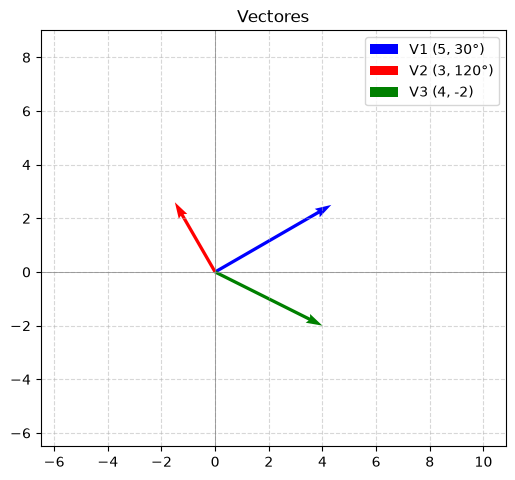

(<Axes: title={'center': 'Vectores'}>, (np.float64(4.330127018922194), np.float64(2.4999999999999996)))
(<Axes: title={'center': 'Vectores'}>, (np.float64(-1.4999999999999993), np.float64(2.598076211353316)))
(<Axes: title={'center': 'Vectores'}>, (np.float64(4.47213595499958), np.float64(-26.56505117707799)))


In [6]:
# Add root folder to sys.path
sys.path.append(str(Path("..").resolve()))

# Import your helper function directly
from helper_functions import plot_vector, plot_vector_xy

# --- Ejemplo de uso combinando ambas funciones ---

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.grid(True, linestyle="--", alpha=0.5)

# just in case is needed we can use ret, normally not used
ret_1 = plot_vector(5, 30, ax=ax, color="b", label="V1 (5, 30°)")
ret_2 = plot_vector(3, 120, ax=ax, color="r", label="V2 (3, 120°)")
ret_3 = plot_vector_xy(4, -2, ax=ax, color="g", label="V3 (4, -2)")

plt.title("Vectores")
plt.show()

print(ret_1)
print(ret_2)
print(ret_3)


#### oom: Order of Magnitude
Manage astropy units as well as only values

In [7]:
# Add root folder to sys.path
sys.path.append(str(Path("..").resolve()))

# Import your helper function directly
from helper_functions import oom

a_e = 1.1494411e-22 * (u.m / u.s**2)
print(f"You accelerates the Earth in the order of magnitude: {oom(a_e)}")

a_val = 1.1494411e-22
print(f"You accelerates the Earth in the order of magnitude: {oom(a_val)}")


You accelerates the Earth in the order of magnitude: 1e-22 m / s2
You accelerates the Earth in the order of magnitude: 1e-22


#### Define custom unit in AstroPy
Define any needed new unit into the AstroPy framework, and then operate normally.

Example:

In [ ]:
# 1. Define custom currency unit
USD = u.def_unit("USD")

# 2. Define the price rate per gram
price_rate = 5 * USD / u.g

# --- Example Usage ---
# Calculate total cost for 2.5 kilograms
mass = 2.5 * u.kg
total_cost = (price_rate * mass).to(USD)

print(f"Price rate: {price_rate}")
print(f"Total cost for {mass}: {total_cost:,.0f}")

Price rate: 5.0 USD / g
Total cost for 2.5 kg: 12,500 USD
